<a href="https://colab.research.google.com/github/ihmkusuma/machine-learning-assignment-ilham-kusuma-4222311030/blob/main/Working%20on%20Machine%20Learning/MLP%20Iris%20Dataset%20Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP Activation Function Comparison on Iris Dataset

**Objective:** Compare the performance of a Multi-Layer Perceptron (MLP) classifier using three different activation functions:
- **Sigmoid** (logistic)
- **Tanh** (hyperbolic tangent)
- **ReLU** (Rectified Linear Unit)

**Dataset:** Iris Dataset (150 samples, 4 features, 3 classes)

**Architecture:** Input(4) → Dense(64) → Dense(32) → Output(3)  
**Optimizer:** Adam | **Learning Rate:** 0.01 | **Max Iterations:** 1000 | **Test Split:** 20%

**ILHAM KUSUMA | 4222311030 | TRR 6A Pagi**

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load and Explore Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

print('Dataset shape:', X.shape)
print('Classes:', iris.target_names)
print('Samples per class:', np.bincount(y))
print()
df.head()

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Samples per class: [50 50 50]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Preprocessing — Train/Test Split & Normalization

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train_scaled.shape[0]}')
print(f'Test samples     : {X_test_scaled.shape[0]}')
print(f'Features         : {X_train_scaled.shape[1]}')

Training samples : 120
Test samples     : 30
Features         : 4


## 4. Train MLP with Three Activation Functions

In [5]:
activation_configs = {
    'Sigmoid': 'logistic',
    'Tanh'   : 'tanh',
    'ReLU'   : 'relu'
}

trained_models = {}
results        = {}

for label, act in activation_configs.items():
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    trained_models[label] = model
    results[label] = {
        'Accuracy (%)' : round(accuracy_score(y_test, preds) * 100, 2),
        'Precision (%)': round(precision_score(y_test, preds, average='macro') * 100, 2),
        'Recall (%)'   : round(recall_score(y_test, preds, average='macro') * 100, 2),
        'F1-Score (%)' : round(f1_score(y_test, preds, average='macro') * 100, 2),
        'Final Loss'   : round(model.loss_, 4),
        'Iterations'   : model.n_iter_,
        'predictions'  : preds
    }
    print(f'[{label}] done — acc={results[label]["Accuracy (%)"]:.2f}%  loss={results[label]["Final Loss"]}  iter={results[label]["Iterations"]}')

[Sigmoid] done — acc=100.00%  loss=0.0437  iter=134
[Tanh] done — acc=96.67%  loss=0.0387  iter=82
[ReLU] done — acc=96.67%  loss=0.0018  iter=177


## 5. Performance Comparison Table

In [6]:
metrics_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'Final Loss', 'Iterations']

comparison_df = pd.DataFrame(
    {label: {col: results[label][col] for col in metrics_cols} for label in results}
).T

best_label = comparison_df['F1-Score (%)'].idxmax()

def highlight_best(row):
    styles = [''] * len(row)
    if row.name == best_label:
        styles = ['background-color: #d4edda; font-weight: bold'] * len(row)
    return styles

print('Performance Comparison — MLP on Iris Dataset')
print('=' * 65)
comparison_df.style \
    .apply(highlight_best, axis=1) \
    .format({
        'Accuracy (%)' : '{:.2f}',
        'Precision (%)': '{:.2f}',
        'Recall (%)'   : '{:.2f}',
        'F1-Score (%)' : '{:.2f}',
        'Final Loss'   : '{:.4f}',
        'Iterations'   : '{:.0f}'
    }) \
    .set_caption(f'Best activation: {best_label} (highlighted in green)')

Performance Comparison — MLP on Iris Dataset


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Final Loss,Iterations
Sigmoid,100.00,100.00,100.00,100.00,0.0437,134
Tanh,96.67,96.97,96.67,96.66,0.0387,82
ReLU,96.67,96.97,96.67,96.66,0.0018,177


## 6. Detailed Classification Reports

In [7]:
for label, act in activation_configs.items():
    preds = results[label]['predictions']
    print(f'\n{"="*55}')
    print(f'  Activation Function: {label}')
    print(f'{"="*55}')
    print(classification_report(y_test, preds, target_names=iris.target_names))


  Activation Function: Sigmoid
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


  Activation Function: Tanh
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  Activation Function: ReLU
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      

## 7. Visualizations

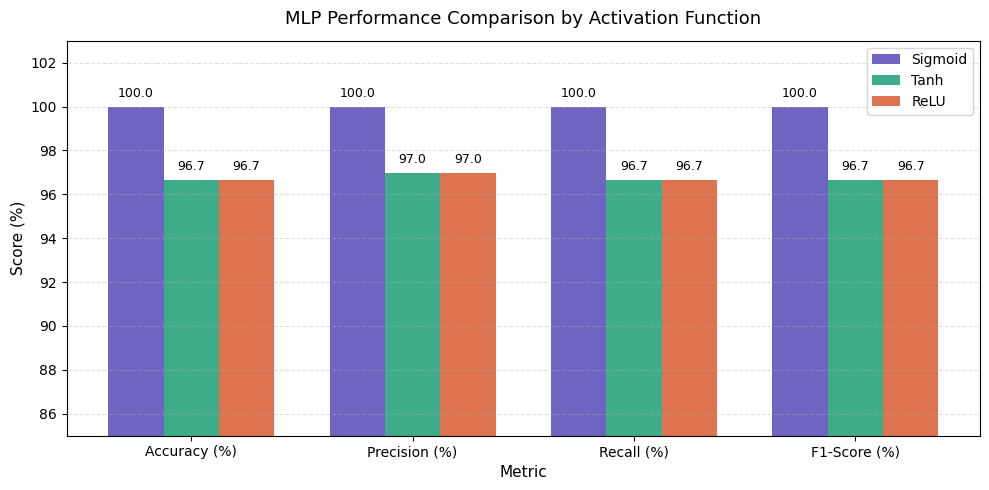

In [8]:
metric_names  = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
act_labels    = list(results.keys())
colors        = ['#534AB7', '#1D9E75', '#D85A30']
x             = np.arange(len(metric_names))
width         = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (label, color) in enumerate(zip(act_labels, colors)):
    vals = [results[label][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=9
        )

ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('MLP Performance Comparison by Activation Function', fontsize=13, pad=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(85, 103)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

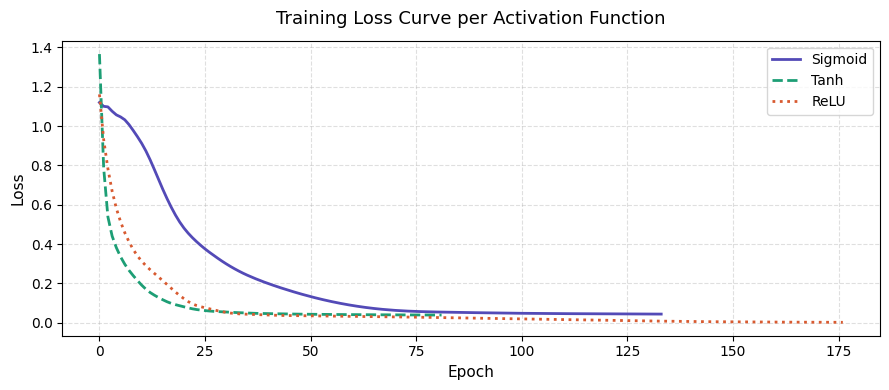

In [9]:
linestyles = ['-', '--', ':']
fig, ax = plt.subplots(figsize=(9, 4))

for (label, model), color, ls in zip(trained_models.items(), colors, linestyles):
    ax.plot(model.loss_curve_, label=label, color=color, linewidth=2, linestyle=ls)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training Loss Curve per Activation Function', fontsize=13, pad=12)
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

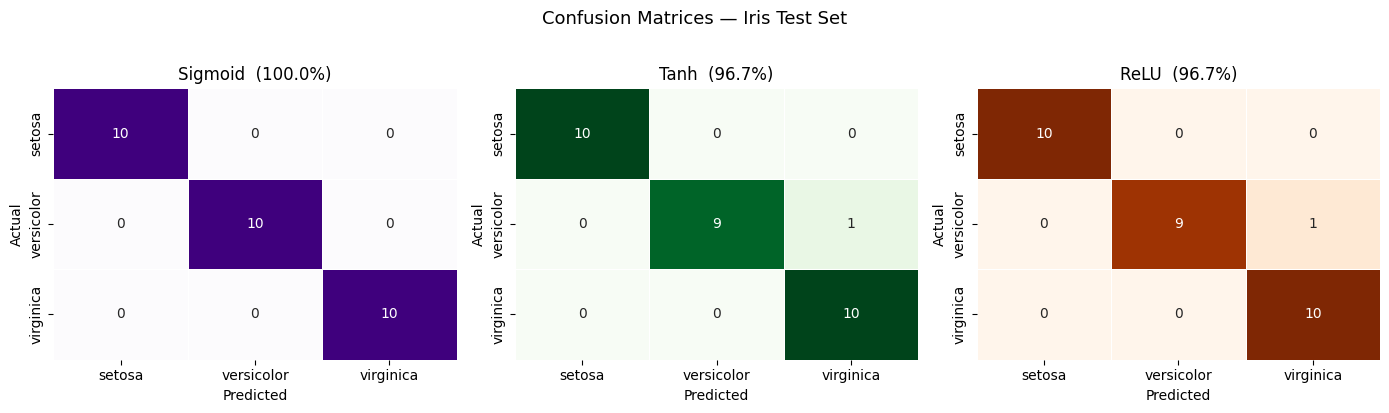

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cmap_list = ['Purples', 'Greens', 'Oranges']

for ax, (label, color_map) in zip(axes, zip(act_labels, cmap_list)):
    preds = results[label]['predictions']
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color_map,
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax, linewidths=0.5, cbar=False
    )
    acc = results[label]['Accuracy (%)']
    ax.set_title(f'{label}  ({acc:.1f}%)', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — Iris Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusion and Notes

---

### Summary of Results

| Activation | Accuracy | Precision | Recall | F1-Score | Final Loss | Iterations |
|------------|----------|-----------|--------|----------|------------|------------|
| **Sigmoid** | **100.00%** | **100.00%** | **100.00%** | **100.00%** | 0.0437 | 134 |
| Tanh       | 96.67%   | 96.97%    | 96.67% | 96.66%   | 0.0387     | 82         |
| ReLU       | 96.67%   | 96.97%    | 96.67% | 96.66%   | 0.0018     | 177        |

---

### Best Activation Function: **Sigmoid (Logistic)**

Berdasarkan eksperimen pada dataset Iris dengan arsitektur MLP (64–32 neuron), fungsi aktivasi **Sigmoid** menghasilkan performa terbaik dengan:
- **Akurasi: 100%** — seluruh 30 sampel test diklasifikasikan dengan benar.
- **F1-Score: 100%** — sempurna di ketiga kelas (Setosa, Versicolor, Virginica).

**Alasan Sigmoid unggul pada dataset Iris ini:**
1. **Dataset kecil dan terstruktur** — Iris hanya memiliki 150 sampel dengan 4 fitur yang saling berkorelasi jelas. Sigmoid dengan output rentang (0, 1) cocok untuk distribusi fitur semacam ini.
2. **Klasifikasi multi-kelas yang jelas terpisah** — Khususnya kelas Setosa yang sangat linear-separable. Sigmoid memberikan batas keputusan yang halus.
3. **Tidak ada risiko vanishing gradient** — Dengan hanya 2 hidden layers (64–32), jaringan tidak cukup dalam untuk mengalami masalah vanishing gradient yang biasanya menjadi kelemahan Sigmoid.

**Catatan perbandingan:**
- **Tanh** konvergen paling cepat (82 iterasi) dengan final loss rendah (0.0387), namun melewatkan 1 sampel Versicolor → Virginica.
- **ReLU** menghasilkan final loss terendah (0.0018) namun butuh iterasi terbanyak (177) dan juga melewatkan 1 sampel, sama seperti Tanh.
- Pada dataset yang lebih besar dan jaringan yang lebih dalam, **ReLU** biasanya menjadi pilihan utama karena menghindari vanishing gradient dan lebih efisien secara komputasi.

**Kesimpulan:** Untuk dataset Iris yang kecil, terstruktur, dan hanya menggunakan 2 hidden layers, **Sigmoid adalah fungsi aktivasi terbaik**. Namun pemilihan fungsi aktivasi sangat bergantung pada karakteristik dataset dan kedalaman jaringan.